# WangChanBERTa Fine-Tuning — FahMai Email Tagger

**Task:** Multi-label classification of Thai customer emails into three categories: สร้างโมเดลจำแนกแบบหลายป้ายกำกับเพื่อจำแนก Tags ของ Gmail
- `is_policy` - คำถามเกี่ยวกับนโยบาย (return, warranty, shipping…)
- `is_product` - คำถามเกี่ยวกับสินค้า (specs, price, availability…)
- `is_store_info` - ขอข้อมูลร้าน (address, contact, hours…)

**Model:** `airesearch/wangchanberta-base-att-spm-uncased`  
**Dataset:** `../train_set.json`  
**Output:** `../models/bert-fahmai-tagger/`

---
### Usage
- **First run :** Run all cells top-to-bottom. The model will save model log at `../models/bert-fahmai-tagger/` and auto re-train after.



In [1]:
# Install / upgrade required packages
import sys
!{sys.executable} -m pip install -q --root-user-action=ignore \
    transformers datasets scikit-learn matplotlib seaborn \
    sentencepiece tiktoken protobuf "accelerate>=1.1.0" mlflow

In [2]:
import os
import json
import shutil
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import mlflow
import mlflow.pyfunc
from mlflow.tracking import MlflowClient

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
set_seed(42)

LABEL_COLS       = ["is_policy", "is_product", "is_store_info"]
MODEL_NAME       = "airesearch/wangchanberta-base-att-spm-uncased"
DATASET_VERSION  = "v1"
DATA_PATH        = f"../data/train_set_{DATASET_VERSION}.json"
OUTPUT_DIR       = "../../models/bert-email-tagger"
MAX_LENGTH       = 512
THRESHOLD        = 0.5
MLFLOW_URI       = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
EXPERIMENT_NAME  = "bert-email-tagger"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"PyTorch         : {torch.__version__}")
print(f"CUDA            : {torch.cuda.is_available()}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Dataset version : {DATASET_VERSION} ({DATA_PATH})")
print(f"MLflow URI      : {MLFLOW_URI}")

d:\conda_envs\AutoGmail\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch         : 2.6.0+cu124
CUDA            : True
Device          : cuda
Dataset version : v1 (../data/train_set_v1.json)
MLflow URI      : http://localhost:5000


## 1. Load Dataset

In [3]:
# Load train_set.json
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Total samples : {len(df)}")
print(f"Columns       : {list(df.columns)}")
df[LABEL_COLS].sum().rename("count").to_frame()

Total samples : 400
Columns       : ['id', 'text', 'is_policy', 'is_product', 'is_store_info']


,count
is_policy,200
is_product,200
is_store_info,200


## 2. Train / Validation / Test Split

In [4]:
# 80 / 10 / 10 split  (random; stratification skipped - multi-label)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

Train : 320
Val   : 40
Test  : 40


In [5]:
print(f"{'':15} {'Train':>8} {'Val':>8} {'Test':>8}")
for col in LABEL_COLS:
    print(f"{col:<15} {train_df[col].mean():>8.2%} {val_df[col].mean():>8.2%} {test_df[col].mean():>8.2%}")

                   Train      Val     Test
is_policy         50.31%   47.50%   50.00%
is_product        49.38%   50.00%   55.00%
is_store_info     50.94%   40.00%   52.50%


## 3. Tokenisation

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    # Stack binary labels into a float tensor list for BCEWithLogitsLoss
    labels = [
        [float(p), float(pr), float(s)]
        for p, pr, s in zip(
            examples["is_policy"],
            examples["is_product"],
            examples["is_store_info"],
        )
    ]
    tokenized["labels"] = labels
    return tokenized

def df_to_hf_dataset(frame: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(frame[["text"] + LABEL_COLS].reset_index(drop=True))
    return ds.map(preprocess, batched=True, remove_columns=["text"] + LABEL_COLS)

print("Tokenising")
train_ds = df_to_hf_dataset(train_df)
val_ds   = df_to_hf_dataset(val_df)
test_ds  = df_to_hf_dataset(test_df)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(  type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format( type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Done.")
print(f"Train tokens sample: {train_ds[0]['input_ids'].shape}")

Tokenising


Map: 100%|██████████| 40/40 [00:00<00:00, 3128.97 examples/s]

Done.
Train tokens sample: torch.Size([512])


## 4. Model

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification",
    id2label={i: l for i, l in enumerate(LABEL_COLS)},
    label2id={l: i for i, l in enumerate(LABEL_COLS)},
)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4598.20it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream tas

Parameters: 105,246,723


## 5. Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))          # sigmoid
    preds = (probs >= THRESHOLD).astype(int)
    macro_f1 = f1_score(labels.astype(int), preds, average="macro", zero_division=0)
    per_label = f1_score(labels.astype(int), preds, average=None, zero_division=0)
    result = {"macro_f1": macro_f1}
    for name, val in zip(LABEL_COLS, per_label):
        result[f"f1_{name}"] = val
    return result

## 6. Training

In [9]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="best",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_epsilon=1e-8,
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    lr_scheduler_type="linear",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Starting training")
trainer.train()

for ckpt in glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-*")):
    shutil.rmtree(ckpt)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 6, 'bos_token_id': 5}.


Starting training


Epoch,Training Loss,Validation Loss,Macro F1,F1 Is Policy,F1 Is Product,F1 Is Store Info
1,2.555799,0.535637,0.818797,0.739130,0.904762,0.812500
2,1.944443,0.438590,0.832565,0.844444,0.947368,0.705882
3,1.524509,0.363881,0.891957,0.863636,0.947368,0.864865
4,1.226403,0.295052,0.922139,0.904762,0.947368,0.914286
5,1.034848,0.282992,0.922670,0.904762,0.974359,0.888889


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


## 7. Evaluation on Test Set

In [10]:
predictions = trainer.predict(test_ds)
logits  = predictions.predictions
y_true  = predictions.label_ids.astype(int)
probs   = 1 / (1 + np.exp(-logits))
y_pred  = (probs >= THRESHOLD).astype(int)

print("Classification Report (per label):")
print(classification_report(y_true, y_pred, target_names=LABEL_COLS, digits=4, zero_division=0))

Classification Report (per label):
               precision    recall  f1-score   support

    is_policy     1.0000    0.9000    0.9474        20
   is_product     0.9565    1.0000    0.9778        22
is_store_info     0.7692    0.9524    0.8511        21

    micro avg     0.8955    0.9524    0.9231        63
    macro avg     0.9086    0.9508    0.9254        63
 weighted avg     0.9079    0.9524    0.9259        63
  samples avg     0.8000    0.8250    0.8000        63



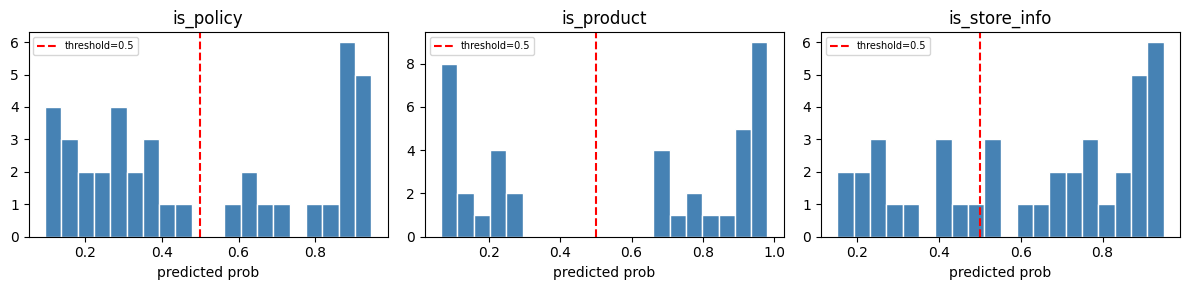

In [11]:
# Per-label probability distribution on test set
fig, axes = plt.subplots(1, len(LABEL_COLS), figsize=(12, 3))
for i, (ax, name) in enumerate(zip(axes, LABEL_COLS)):
    ax.hist(probs[:, i], bins=20, color="steelblue", edgecolor="white")
    ax.axvline(THRESHOLD, color="red", linestyle="--", label=f"threshold={THRESHOLD}")
    ax.set_title(name)
    ax.set_xlabel("predicted prob")
    ax.legend(fontsize=7)
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "prob_dist.png"))
plt.show()

In [12]:
del trainer
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 8. Save Final Model

In [13]:
import datetime

os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

report_str = classification_report(y_true, y_pred, target_names=LABEL_COLS, digits=4, zero_division=0)
macro_f1   = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
per_label  = f1_score(y_true, y_pred, average=None, zero_division=0)
macro_prec = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
macro_rec  = float(f1_score(y_true, y_pred, average="macro", zero_division=0))

meta = {
    "trained_at":      datetime.datetime.utcnow().isoformat() + "Z",
    "base_model":      MODEL_NAME,
    "dataset_version": DATASET_VERSION,
    "dataset_path":    DATA_PATH,
    "labels":          LABEL_COLS,
    "threshold":       THRESHOLD,
    "train_samples":   len(train_df),
    "val_samples":     len(val_df),
    "test_samples":    len(test_df),
    "macro_f1_test":   macro_f1,
}

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.80s/it]


In [14]:
with open(os.path.join(OUTPUT_DIR, "train_meta.json"), "w") as mf:
    json.dump(meta, mf, indent=2)

with mlflow.start_run(run_name=f"notebook-{DATASET_VERSION}") as run:
    mlflow.log_param("base_model",       MODEL_NAME)
    mlflow.log_param("dataset_version",  DATASET_VERSION)
    mlflow.log_param("dataset_path",     DATA_PATH)
    mlflow.log_param("max_length",       MAX_LENGTH)
    mlflow.log_param("threshold",        THRESHOLD)
    mlflow.log_param("train_samples",    len(train_df))
    mlflow.log_param("val_samples",      len(val_df))
    mlflow.log_param("test_samples",     len(test_df))

    mlflow.log_param("learning_rate",               training_args.learning_rate)
    mlflow.log_param("num_train_epochs",            training_args.num_train_epochs)
    mlflow.log_param("per_device_train_batch_size", training_args.per_device_train_batch_size)
    mlflow.log_param("gradient_accumulation_steps", training_args.gradient_accumulation_steps)
    mlflow.log_param("effective_batch_size",
                     training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
    mlflow.log_param("warmup_ratio",               training_args.warmup_ratio)
    mlflow.log_param("weight_decay",               training_args.weight_decay)
    mlflow.log_param("lr_scheduler_type",          training_args.lr_scheduler_type)
    mlflow.log_param("fp16",                       training_args.fp16)
    mlflow.log_param("adam_beta1",                 training_args.adam_beta1)
    mlflow.log_param("adam_beta2",                 training_args.adam_beta2)
    mlflow.log_param("adam_epsilon",               training_args.adam_epsilon)
    mlflow.log_param("metric_for_best_model",      training_args.metric_for_best_model)

    mlflow.log_metric("macro_f1",        macro_f1)
    mlflow.log_metric("macro_precision", macro_prec)
    mlflow.log_metric("macro_recall",    macro_rec)
    for name, val in zip(LABEL_COLS, per_label):
        mlflow.log_metric(f"f1_{name}", float(val))

    mlflow.log_text(report_str, "classification_report.txt")
    mlflow.log_figure(fig, "prob_dist.png")
    mlflow.log_artifact(os.path.join(OUTPUT_DIR, "train_meta.json"))

    mlflow.transformers.log_model(
        transformers_model={"model": model, "tokenizer": tokenizer},
        artifact_path="model",
        task="text-classification",
    )

    mv = mlflow.register_model(
        model_uri=f"runs:/{run.info.run_id}/model",
        name=EXPERIMENT_NAME,
    )
    MlflowClient().transition_model_version_stage(
        name=EXPERIMENT_NAME,
        version=mv.version,
        stage="Production",
        archive_existing_versions=True,
    )
    run_id = run.info.run_id

print(f"Model saved to  : {OUTPUT_DIR}")
print(f"MLflow run_id   : {run_id}")
print(f"Registry version: v{mv.version} → Production")
print(json.dumps(meta, indent=2))

2026/05/07 12:21:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.46it/s]
2026/05/07 12:21:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 12:21:29 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 12:21:29 WARNING mlflow.utils.environment: On Wi

🏃 View run notebook-v1 at: http://localhost:5000/#/experiments/1/runs/54264e060f824387b87c0f512029457f
🧪 View experiment at: http://localhost:5000/#/experiments/1
Model saved to  : ../../models/bert-email-tagger
MLflow run_id   : 54264e060f824387b87c0f512029457f
Registry version: v1 → Production
{
  "trained_at": "2026-05-07T05:21:23.335548Z",
  "base_model": "airesearch/wangchanberta-base-att-spm-uncased",
  "dataset_version": "v1",
  "dataset_path": "../data/train_set_v1.json",
  "labels": [
    "is_policy",
    "is_product",
    "is_store_info"
  ],
  "threshold": 0.5,
  "train_samples": 320,
  "val_samples": 40,
  "test_samples": 40,
  "macro_f1_test": 0.9254033428725478
}
